In [2]:
#загрузка и проверки корректности
import pandas as pd

df = pd.read_csv('train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#сколько пассажиров
df.shape

(891, 12)

In [4]:
#пропуски
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#признаки
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
#характеристики числовых признаков
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#количество выживыших и умерших
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
#доля выживших
len(df[df['Survived'] == 1]) / 891 * 100

38.38383838383838

In [9]:
#анализ по полу
df[['Sex', 'Survived']].value_counts()

Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

In [10]:
#инф по выжившим женщинам
df[(df['Sex'] == 'female') & (df['Survived'] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S


In [11]:
#анализ по классу
df.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

<Axes: ylabel='Frequency'>

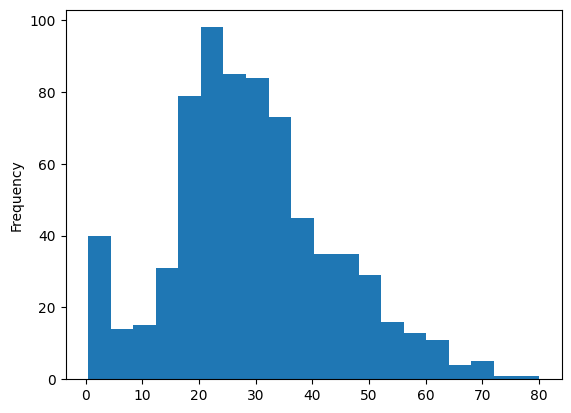

In [12]:
#график по возрасту
df['Age'].plot(kind='hist', bins=20)

In [13]:
#анализ пропусков
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
#анализ по полу
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [15]:
#анализ по классу
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
#анализ по порту посадки
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Sex'>

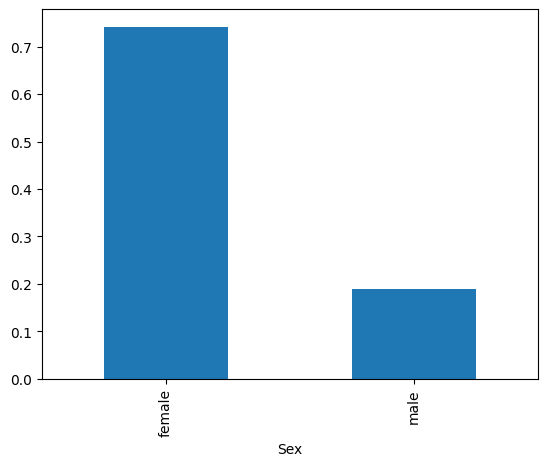

In [17]:
#выживаемость по полу
df.groupby('Sex')['Survived'].mean().plot(kind='bar')

<Axes: xlabel='Pclass'>

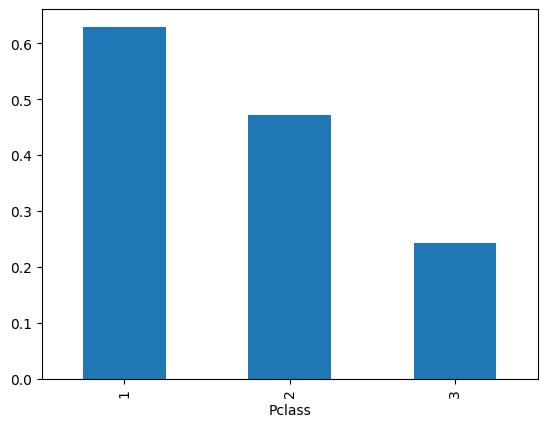

In [18]:
#выживаемость по классу
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

<Axes: ylabel='Frequency'>

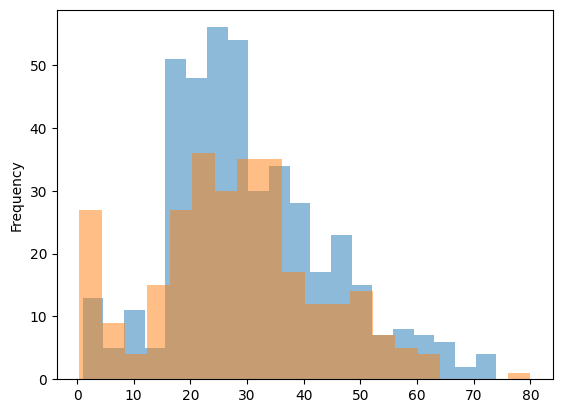

In [19]:
#выживаемость по возрасту
df[df['Survived'] == 0]['Age'].plot(kind='hist', bins=20, alpha=0.5)
df[df['Survived'] == 1]['Age'].plot(kind='hist', bins=20, alpha=0.5)

In [20]:
#создали возр группы
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 50, 100],
    labels=['0-18', '18-30', '30-50', '50+']
)

In [21]:
#анализ по возр группам
df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

AgeGroup
0-18     50.359712
18-30    35.555556
30-50    42.323651
50+      34.375000
Name: Survived, dtype: float64

<Axes: ylabel='Frequency'>

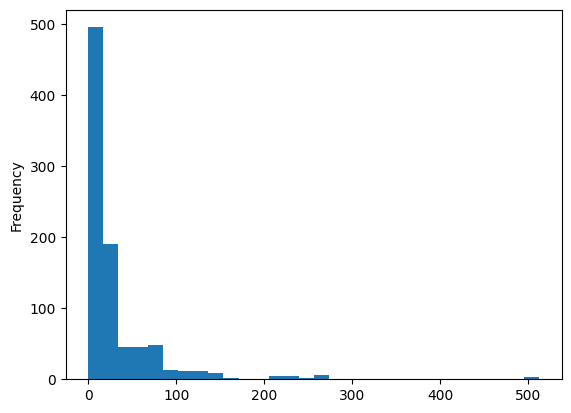

In [22]:
#анализ по стоимости
df['Fare'].plot(kind='hist', bins=30)

In [23]:
#группы по стоимости
df['FareGroup'] = pd.cut(
    df['Fare'],
    bins=[0, 10, 30, 60, 100, 600],
    labels=['0-10', '10-30', '30-60', '60-100', '100+']
)

df.groupby('FareGroup', observed=True)['Survived'].mean() * 100

FareGroup
0-10      20.560748
10-30     43.302181
30-60     48.214286
60-100    62.318841
100+      73.584906
Name: Survived, dtype: float64

<Axes: title={'center': 'Fare'}, xlabel='Pclass'>

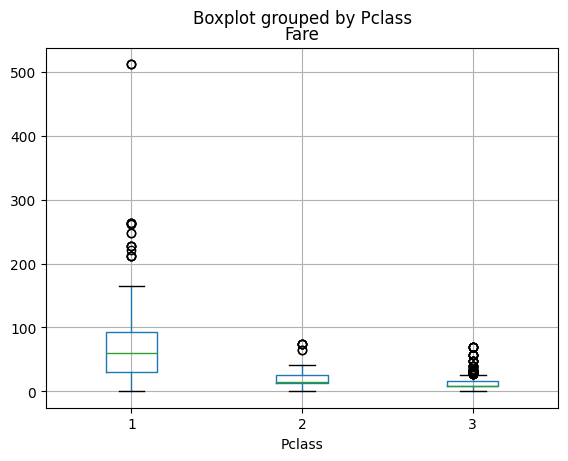

In [24]:
#анализ по стоимости и классу
df.boxplot(column='Fare', by='Pclass')

In [25]:
#пол класс выживаемость
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100

Sex,female,male
Pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669


<Axes: xlabel='Pclass'>

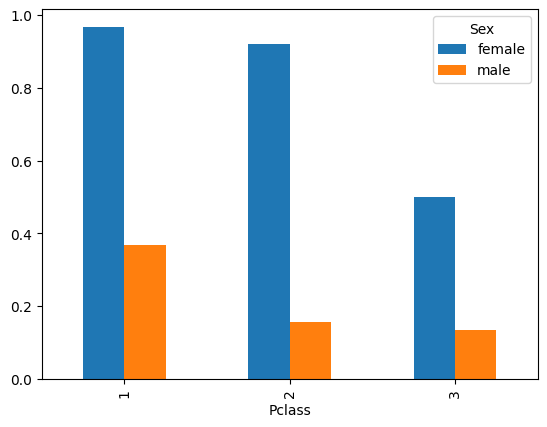

In [26]:
#отображаем на графике
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().plot(kind='bar')

In [27]:
#разделение по признакам и переменной
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

In [28]:
#здесь загрузила нужные библиотеки
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [29]:
#делим признаки по типу
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

In [30]:
#пропуси заменяем медианой
numeric_transformer = SimpleImputer(strategy='median')

In [31]:
#пропуси заменяем частым значением текст=числа
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [32]:
#числа обр 1 способом категориальные другим
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [33]:
#делим на обучвющую и тестовую
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
#создаем модель и объем 2 этапа
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [35]:
#зависимость между признаками и фактом выживания
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [36]:
#получаем предсказание
y_pred = model.predict(X_test)

In [37]:
#оценка модели
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [38]:
#пошло дерево решений
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, tree_pred))

Accuracy: 0.7653631284916201


In [39]:
#100 деревьев решений дает прогноз, потом объед их результат
from sklearn.ensemble import RandomForestClassifier

forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, forest_pred))

Accuracy: 0.8156424581005587


In [40]:
#смотрим на 5 ближайших пассажиров и определяем класс на основе них
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, knn_pred))

Accuracy: 0.6703910614525139


In [41]:
#проверяем как работает модель
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [42]:
#обучаем дерево решений
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, tree_pred))

Accuracy: 0.7653631284916201


In [43]:
#теперь обучаем рандом форест
from sklearn.ensemble import RandomForestClassifier

forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, forest_pred))

Accuracy: 0.8156424581005587


In [44]:
#XGBoost — обучение модели
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, xgb_pred))

Accuracy: 0.7932960893854749


In [45]:
#CatBoost
from catboost import CatBoostClassifier

cat_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(
        iterations=100,
        depth=5,
        learning_rate=0.1,
        random_seed=42,
        verbose=False
    ))
])

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, cat_pred))

Accuracy: 0.8044692737430168


In [46]:
#масштабируем осн признаки
from sklearn.preprocessing import StandardScaler

numeric_transformer_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_knn = ColumnTransformer([
    ('num', numeric_transformer_knn, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [47]:
#прогноз по ближ 5 пасс
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, knn_pred))

Accuracy: 0.8156424581005587


In [48]:
#cравниваем модели
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'CatBoost',
        'KNN'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, cat_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.765363
2,Random Forest,0.815642
3,XGBoost,0.793296
4,CatBoost,0.804469
5,KNN,0.815642


In [49]:
X_train_processed = forest_model.named_steps['preprocessor'].transform(X_train)
X_test_processed = forest_model.named_steps['preprocessor'].transform(X_test)
feature_names = forest_model.named_steps['preprocessor'].get_feature_names_out()

feature_names

array(['num__Pclass', 'num__Age', 'num__SibSp', 'num__Parch', 'num__Fare',
       'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S'], dtype=object)

In [50]:
explainer = shap.TreeExplainer(
    forest_model.named_steps['model']
)

NameError: name 'shap' is not defined

In [ ]:
shap_values = explainer.shap_values(X_test_processed)

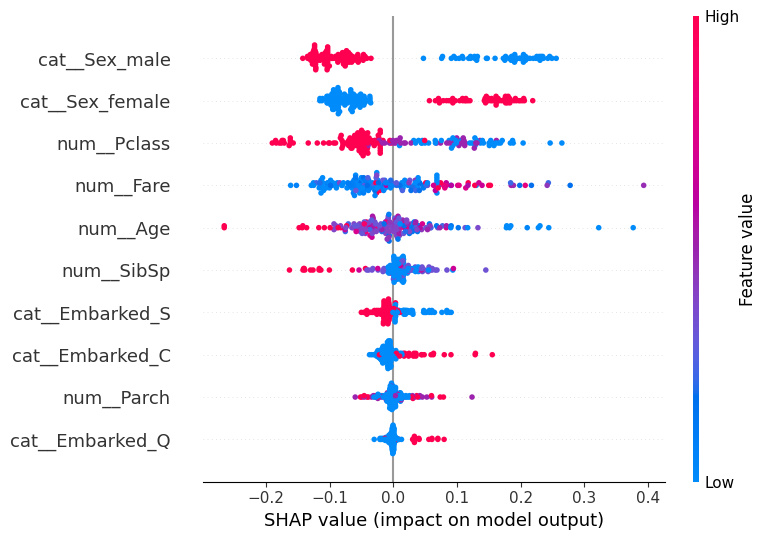

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_processed,
    feature_names=feature_names
)

SHAP-анализ показал, что наибольшее влияние на прогноз Random Forest оказывают признаки пола пассажира (Sex) и класса (Pclass). Также заметный вклад имеют стоимость билета (Fare) и возраст (Age). SHAP позволяет не только оценить важность признаков, но и понять направление их влияния на прогноз модели.

In [ ]:
predictions = {
    'Logistic Regression': y_pred,
    'Decision Tree': tree_pred,
    'Random Forest': forest_pred,
    'XGBoost': xgb_pred,
    'CatBoost': cat_pred,
    'KNN': knn_pred
}

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = []

for name, pred in predictions.items():
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

metrics_df = pd.DataFrame(metrics)

metrics_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Decision Tree,0.765363,0.754717,0.579710,0.655738
2,Random Forest,0.815642,0.800000,0.695652,0.744186
3,XGBoost,0.793296,0.785714,0.637681,0.704000
4,CatBoost,0.804469,0.869565,0.579710,0.695652
5,KNN,0.815642,0.800000,0.695652,0.744186


<Axes: title={'center': 'Сравнение моделей по Accuracy'}, xlabel='Model'>

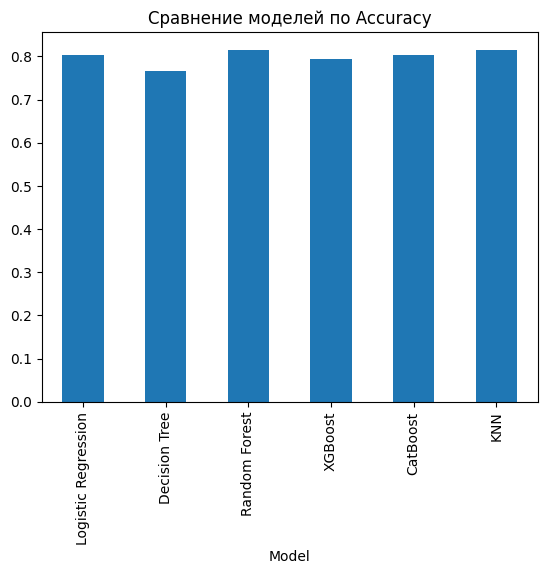

In [ ]:
metrics_df.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False,
    title='Сравнение моделей по Accuracy'
)

<Axes: title={'center': 'Сравнение моделей'}, xlabel='Model'>

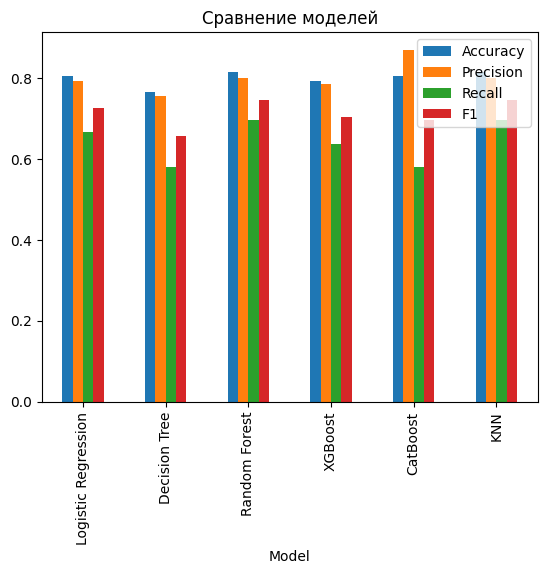

In [ ]:
metrics_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1'
]].plot(
    kind='bar',
    title='Сравнение моделей'
)

Вывод
В работе был проведён анализ датасета Titanic, выполнена предварительная обработка данных и построены модели машинного обучения для прогнозирования выживания пассажиров.
Были рассмотрены Logistic Regression, Decision Tree, Random Forest, XGBoost, CatBoost и KNN.
Для сравнения моделей использовались Accuracy, Precision, Recall и F1-score.
Дополнительно проведён SHAP-анализ Random Forest, который позволил определить наиболее значимые признаки для прогнозирования.
Наибольшее влияние на прогноз модели оказали пол пассажира и класс, а также стоимость билета и возраст.

[10, 3, 25, 7]


[31, 12, 44, 25]
